<a href="https://colab.research.google.com/github/kumarianshika4321-star/ds_anshika/blob/main/Consumer360.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

# SECTION 1: SETUP AND INSTALLATIONS

# Install required libraries
!pip install pandas numpy faker lifetimes mlxtend openpyxl xlrd plotly seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
import datetime
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For RFM and CLV
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# For Market Basket Analysis
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# For Google Colab file upload
from google.colab import files
import io

print(" Setup complete! All libraries imported.")

# ============================================
# SECTION 2: UPLOAD YOUR DATASET
# ============================================

print("\n /content/Sample_ Superstore.csv")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n File uploaded: {filename}")

# Load the data based on file extension
if filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
elif filename.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(io.BytesIO(uploaded[filename]))
else:
    raise ValueError("Please upload a CSV or Excel file")

print(f"\n Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 36.0 MB/s eta 0:00:00
 Setup complete! All libraries imported.

 /content/Sample_ Superstore.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saving Sample_ Superstore.csv to Sample_ Superstore.csv

 File uploaded: Sample_ Superstore.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


 Data loaded successfully!
Shape: (9994, 19)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:

# SECTION 3: DATA EXPLORATION AND CLEANING

print("🔍 DATA EXPLORATION")
print("="*60)

# 1. Basic info
print("\n Dataset Info:")
print("-"*30)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

# 2. Data types and missing values
print("\n Data Types & Missing Values:")
print("-"*30)
data_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(data_info)

# 3. Statistical summary of numerical columns
print("\n📊 Numerical Columns Summary:")
print("-"*30)
print(df.describe())

# 4. Check unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n Categorical Columns Unique Values:")
print("-"*30)
for col in categorical_cols[:10]:  # Show first 10 categorical columns
    print(f"{col}: {df[col].nunique():,} unique values")

# ============================================
# SECTION 4: DATA CLEANING AND PREPARATION
# ============================================

print("\n DATA CLEANING")
print("="*60)

# Create a clean copy
df_clean = df.copy()

# 1. Standardize column names (remove spaces, special characters)
df_clean.columns = df_clean.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
print(" Standardized column names")

# 2. Handle Order Date - Convert to datetime
# Your date column might be named differently - adjust if needed
date_column = None
for col in df_clean.columns:
    if 'order' in col.lower() and 'date' in col.lower():
        date_column = col
        break

if date_column:
    print(f"\n Processing date column: {date_column}")

    # Check current format
    print(f"Sample dates: {df_clean[date_column].iloc[:5].tolist()}")

    # Convert to datetime
    try:
        df_clean['order_date'] = pd.to_datetime(df_clean[date_column], errors='coerce')
        print(" Converted to datetime")
    except:
        # If automatic conversion fails, try manual parsing
        df_clean['order_date'] = pd.to_datetime(df_clean[date_column], format='%m/%d/%Y', errors='coerce')
        print(" Converted using format '%m/%d/%Y'")

    # Drop rows with invalid dates
    initial_rows = len(df_clean)
    df_clean = df_clean.dropna(subset=['order_date'])
    print(f" Removed {initial_rows - len(df_clean)} rows with invalid dates")
else:
    print(" No date column found. Please check your column names.")

# 3. Handle numerical columns
# Identify quantity, sales, discount, profit columns
quantity_col = None
sales_col = None
discount_col = None
profit_col = None

for col in df_clean.columns:
    col_lower = col.lower()
    if 'quant' in col_lower:
        quantity_col = col
    elif 'sales' in col_lower or 'revenue' in col_lower or 'amount' in col_lower:
        sales_col = col
    elif 'discount' in col_lower:
        discount_col = col
    elif 'profit' in col_lower:
        profit_col = col

# Convert to numeric
for col_name, col_var in [('Quantity', quantity_col),
                          ('Sales', sales_col),
                          ('Discount', discount_col),
                          ('Profit', profit_col)]:
    if col_var:
        df_clean[col_var] = pd.to_numeric(df_clean[col_var], errors='coerce')
        print(f" Converted {col_name} column: {col_var}")

# 4. Handle missing values
print("\n📊 Missing Values After Cleaning:")
print("-"*30)
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) > 0:
    print(missing_after)

    # Fill or drop based on column type
    for col in missing_after.index:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col].fillna(0, inplace=True)
            print(f" Filled missing values in {col} with 0")
        else:
            df_clean[col].fillna('Unknown', inplace=True)
            print(f" Filled missing values in {col} with 'Unknown'")
else:
    print("No missing values found!")

# 5. Remove duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"\n Removed {initial_rows - len(df_clean)} duplicate rows")

# 6. Remove negative or zero values where inappropriate
if quantity_col:
    initial_rows = len(df_clean)
    df_clean = df_clean[df_clean[quantity_col] > 0]
    print(f" Removed {initial_rows - len(df_clean)} rows with quantity <= 0")

# Save cleaned data
df_clean.to_csv('cleaned_data.csv', index=False)
print("\n Saved cleaned data to 'cleaned_data.csv'")

print(f"\n Final cleaned dataset shape: {df_clean.shape}")
print("\nSample of cleaned data:")
df_clean.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

🔍 DATA EXPLORATION

 Dataset Info:
------------------------------
Total rows: 9,994
Total columns: 19

Column names:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Segment
8. Country
9. City
10. State
11. Region
12. Product ID
13. Category
14. Sub-Category
15. Product Name
16. Sales
17. Quantity
18. Discount
19. Profit

 Data Types & Missing Values:
------------------------------
             Data Type  Non-Null Count  Null Count  Null Percentage
Row ID           int64            9994           0              0.0
Order ID        object            9994           0              0.0
Order Date      object            9994           0              0.0
Ship Date       object            9994           0              0.0
Ship Mode       object            9994           0              0.0
Customer ID     object            9994           0              0.0
Segment         object            9994           0              0.0
Country         object            9994  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


 Removed 0 duplicate rows
 Removed 0 rows with quantity <= 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


 Saved cleaned data to 'cleaned_data.csv'

 Final cleaned dataset shape: (4042, 20)

Sample of cleaned data:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,order_date
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11-08
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11-08
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06-12
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10-11
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10-11


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# SECTION 5: CREATE CUSTOMER 360 VIEW


print("CREATING CUSTOMER 360 VIEW")
print("="*60)

# Identify key columns based on your data structure
# Adjust these based on your actual column names

# Customer identifier
customer_id_col = None
for col in df_clean.columns:
    if 'customer' in col.lower() and ('id' in col.lower() or 'code' in col.lower()):
        customer_id_col = col
        break

if not customer_id_col:
    # Try to find any ID column
    for col in df_clean.columns:
        if 'id' in col.lower() and 'order' not in col.lower():
            customer_id_col = col
            break

print(f" Using customer ID column: {customer_id_col}")

# Order ID column
order_id_col = None
for col in df_clean.columns:
    if 'order' in col.lower() and 'id' in col.lower():
        order_id_col = col
        break

print(f" Using order ID column: {order_id_col}")

# Region column
region_col = None
for col in df_clean.columns:
    if 'region' in col.lower():
        region_col = col
        break

print(f" Using region column: {region_col}")

# Segment column
segment_col = None
for col in df_clean.columns:
    if 'segment' in col.lower():
        segment_col = col
        break

print(f" Using segment column: {segment_col}")

# 1. Calculate customer metrics
print("\n Calculating customer metrics...")

# Get current date for recency calculation
current_date = df_clean['order_date'].max()

# Group by customer
customer_metrics = df_clean.groupby(customer_id_col).agg({
    'order_date': ['min', 'max', 'count'],
    order_id_col: 'nunique',
    sales_col: 'sum',
    quantity_col: 'sum',
    profit_col: 'sum'
}).round(2)

# Flatten column names
customer_metrics.columns = [
    'first_purchase',
    'last_purchase',
    'transaction_lines',
    'total_orders',
    'total_sales',
    'total_quantity',
    'total_profit'
]
customer_metrics = customer_metrics.reset_index()

# Calculate key metrics
customer_metrics['recency_days'] = (current_date - customer_metrics['last_purchase']).dt.days
customer_metrics['customer_lifetime_days'] = (customer_metrics['last_purchase'] - customer_metrics['first_purchase']).dt.days
customer_metrics['avg_order_value'] = customer_metrics['total_sales'] / customer_metrics['total_orders']
customer_metrics['avg_items_per_order'] = customer_metrics['total_quantity'] / customer_metrics['total_orders']
customer_metrics['profit_margin'] = (customer_metrics['total_profit'] / customer_metrics['total_sales'] * 100).round(2)

print(f" Calculated metrics for {len(customer_metrics)} customers")

# 2. Merge with demographic info
print("\n Adding demographic information...")

# Get unique customer info (first occurrence)
if segment_col and region_col:
    customer_demo = df_clean.groupby(customer_id_col).agg({
        segment_col: 'first',
        region_col: 'first'
    }).reset_index()

    # Merge with metrics
    customer_360 = customer_metrics.merge(customer_demo, on=customer_id_col, how='left')
    print(" Added segment and region information")
else:
    customer_360 = customer_metrics
    print(" No demographic columns found")

# 3. Add customer value tiers
print("\n Creating customer value tiers...")

# Create value tiers based on total sales
customer_360['value_tier'] = pd.qcut(
    customer_360['total_sales'],
    q=4,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum'],
    duplicates='drop'
)

customer_360['frequency_tier'] = pd.qcut(
    customer_360['total_orders'],
    q=3,  # Changed from 4 to 3
    labels=['Occasional', 'Regular', 'Frequent'], # Adjusted labels to match q=3
    duplicates='drop'
)

print(f"\n Customer 360 view created successfully!")
print(f"\nSample of customer 360 data:")
customer_360.head()

# Save customer 360 view
customer_360.to_csv('customer_360.csv', index=False)
print("\n Saved customer_360.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

CREATING CUSTOMER 360 VIEW
 Using customer ID column: Customer_ID
 Using order ID column: Order_ID
 Using region column: Region
 Using segment column: Segment

 Calculating customer metrics...
 Calculated metrics for 738 customers

 Adding demographic information...
 Added segment and region information

 Creating customer value tiers...

 Customer 360 view created successfully!

Sample of customer 360 data:

 Saved customer_360.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# SECTION 6: RFM SEGMENTATION

print(" PERFORMING RFM SEGMENTATION")
print("="*60)

def calculate_rfm_scores(df, customer_id_col, recency_col, frequency_col, monetary_col):
    """
    Calculate RFM scores (1-5) for all customers
    """

    # Create RFM dataframe
    rfm_df = df[[customer_id_col, recency_col, frequency_col, monetary_col]].copy()

    # Handle customers with no purchases or infinite values
    rfm_df[recency_col] = rfm_df[recency_col].fillna(999)
    rfm_df[frequency_col] = rfm_df[frequency_col].fillna(0)
    rfm_df[monetary_col] = rfm_df[monetary_col].fillna(0)

    # Create masks for customers with purchases
    mask_purchased = rfm_df[frequency_col] > 0

    print("\n Calculating RFM scores...")

    # 1. Recency Score (R) - lower days = better
    if mask_purchased.sum() > 0:
        # Only score customers with purchases
        rfm_df.loc[mask_purchased, 'R_Score'] = pd.qcut(
            rfm_df.loc[mask_purchased, recency_col],
            q=5,
            labels=[5, 4, 3, 2, 1],  # 5 = most recent (lowest days)
            duplicates='drop'
        ).astype(int)

        # Customers with no purchases get score 1
        rfm_df.loc[~mask_purchased, 'R_Score'] = 1
    else:
        rfm_df['R_Score'] = 1

    # 2. Frequency Score (F) - higher frequency = better
    if rfm_df[frequency_col].nunique() > 5:
        rfm_df['F_Score'] = pd.qcut(
            rfm_df[frequency_col].rank(method='first'),
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates='drop'
        ).astype(int)
    else:
        # If not enough unique values, use custom bins
        bins = [0, 1, 2, 3, 5, float('inf')]
        labels = [1, 2, 3, 4, 5]
        rfm_df['F_Score'] = pd.cut(rfm_df[frequency_col], bins=bins, labels=labels, right=False).astype(int)

    # 3. Monetary Score (M) - higher monetary = better
    if rfm_df[monetary_col].nunique() > 5:
        rfm_df['M_Score'] = pd.qcut(
            rfm_df[monetary_col].rank(method='first'),
            q=5,
            labels=[1, 2, 3, 4, 5],
            duplicates='drop'
        ).astype(int)
    else:
        # If not enough unique values, use custom bins
        bins = [0, 100, 500, 1000, 5000, float('inf')]
        labels = [1, 2, 3, 4, 5]
        rfm_df['M_Score'] = pd.cut(rfm_df[monetary_col], bins=bins, labels=labels, right=False).astype(int)

    # Combine scores
    rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
    rfm_df['RFM_Total'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

    return rfm_df

# Apply RFM calculation
rfm_results = calculate_rfm_scores(
    customer_360,
    customer_id_col='Customer_ID', # Changed 'customer_id' to 'Customer_ID'
    recency_col='recency_days',
    frequency_col='total_orders',
    monetary_col='total_sales'
)

print("\n RFM scores calculated")
print(f"\nRFM Score distribution:")
print(rfm_results['RFM_Total'].value_counts().sort_index())

# ============================================
# SECTION 7: CUSTOMER SEGMENTATION
# ============================================

print("\n ASSIGNING CUSTOMER SEGMENTS")
print("="*60)

def assign_customer_segments(rfm_df):
    """
    Assign meaningful segment names based on RFM scores
    """

    segments = []

    for _, row in rfm_df.iterrows():
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

        if row['total_orders'] == 0:
            segments.append('Inactive')
        elif r >= 4 and f >= 4 and m >= 4:
            segments.append('Champions')
        elif r >= 4 and f >= 3 and m >= 3:
            segments.append('Loyal Customers')
        elif r >= 3 and f >= 3 and m >= 3:
            segments.append('Potential Loyalists')
        elif r >= 4 and f <= 2:
            segments.append('New Customers')
        elif r >= 3 and f <= 2:
            segments.append('Promising')
        elif r <= 2 and f >= 4 and m >= 4:
            segments.append('At Risk Champions')
        elif r <= 2 and f >= 3:
            segments.append('At Risk')
        elif r <= 2 and f <= 2 and m <= 2:
            segments.append('Hibernating')
        elif r <= 2 and f <= 1:
            segments.append('Lost')
        else:
            segments.append('Other')

    rfm_df['Customer_Segment'] = segments
    return rfm_df

# Add segmentation
customer_360_with_rfm = customer_360.merge(
    rfm_results[[customer_id_col, 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total']],
    on=customer_id_col,
    how='left'
)

customer_360_with_rfm = assign_customer_segments(customer_360_with_rfm)

# Display segment distribution
print("\n Customer Segment Distribution:")
segment_dist = customer_360_with_rfm['Customer_Segment'].value_counts()
for segment, count in segment_dist.items():
    percentage = (count / len(customer_360_with_rfm) * 100)
    print(f"{segment:20s}: {count:5d} ({percentage:.1f}%)")

# Save results
customer_360_with_rfm.to_csv('customer_segments.csv', index=False)
print("\n Saved customer segments to 'customer_segments.csv'")

# Show sample of top customers
print("\n Top Champions:")
champions = customer_360_with_rfm[customer_360_with_rfm['Customer_Segment'] == 'Champions'].nlargest(5, 'total_sales')
print(champions[[customer_id_col, 'total_sales', 'total_orders', 'avg_order_value']].head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

 PERFORMING RFM SEGMENTATION

 Calculating RFM scores...

 RFM scores calculated

RFM Score distribution:
RFM_Total
3.0     36
4.0     36
5.0     66
6.0     55
7.0     49
8.0     73
9.0     79
10.0    76
11.0    78
12.0    71
13.0    48
14.0    47
15.0    24
Name: count, dtype: int64

 ASSIGNING CUSTOMER SEGMENTS

 Customer Segment Distribution:
Hibernating         :   116 (15.7%)
Champions           :   109 (14.8%)
Other               :   102 (13.8%)
At Risk             :    78 (10.6%)
Loyal Customers     :    73 (9.9%)
New Customers       :    70 (9.5%)
Potential Loyalists :    66 (8.9%)
Promising           :    52 (7.0%)
At Risk Champions   :    43 (5.8%)
Lost                :    29 (3.9%)

 Saved customer segments to 'customer_segments.csv'

 Top Champions:
    Customer_ID  total_sales  total_orders  avg_order_value
391    KF-16285      9536.56             4        2384.1400
457    ME-17320      8866.71             5        1773.3420
215    DR-12940      7426.90             4      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

 CREATING VISUALIZATION DASHBOARD


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

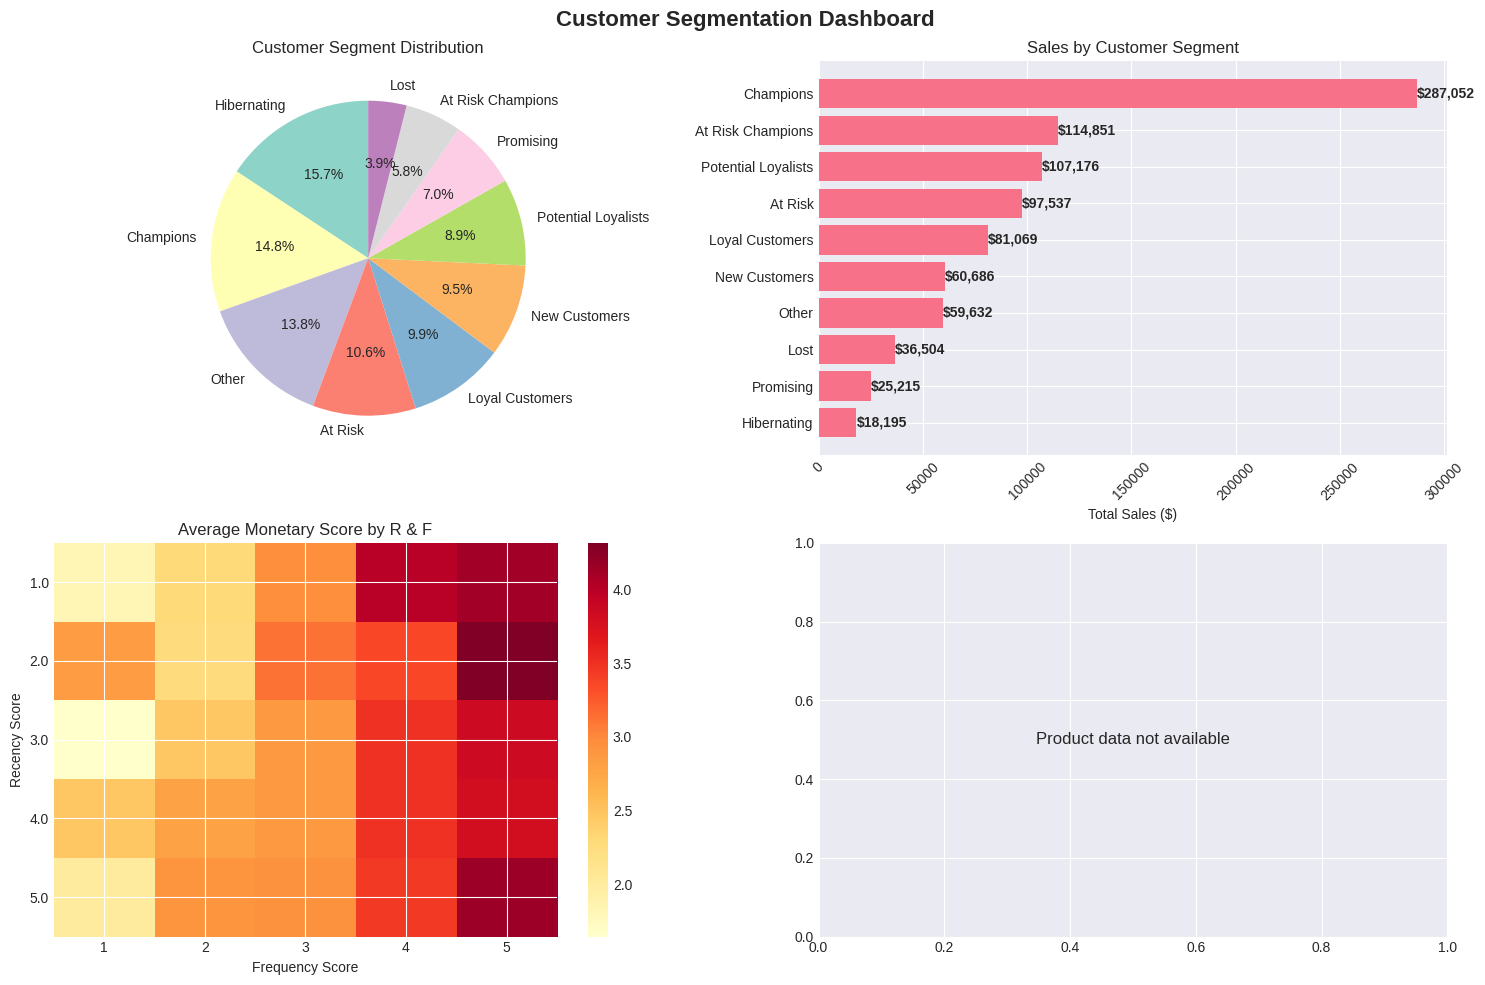

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


📊 Creating Interactive Dashboard...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [8]:

# SECTION 8: VISUALIZATION DASHBOARD

print(" CREATING VISUALIZATION DASHBOARD")
print("="*60)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Customer Segment Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Customer Segmentation Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Segment Distribution (Pie Chart)
ax1 = axes[0, 0]
segment_counts = customer_360_with_rfm['Customer_Segment'].value_counts()
colors = plt.cm.Set3(range(len(segment_counts)))
wedges, texts, autotexts = ax1.pie(segment_counts.values,
                                    labels=segment_counts.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90)
ax1.set_title('Customer Segment Distribution')

# Plot 2: Sales by Segment (Bar Chart)
ax2 = axes[0, 1]
segment_sales = customer_360_with_rfm.groupby('Customer_Segment')['total_sales'].sum().sort_values(ascending=True)
bars = ax2.barh(range(len(segment_sales)), segment_sales.values)
ax2.set_yticks(range(len(segment_sales)))
ax2.set_yticklabels(segment_sales.index)
ax2.set_xlabel('Total Sales ($)')
ax2.set_title('Sales by Customer Segment')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, segment_sales.values)):
    ax2.text(val, bar.get_y() + bar.get_height()/2, f'${val:,.0f}',
             ha='left', va='center', fontweight='bold')

# Plot 3: RFM Score Heatmap
ax3 = axes[1, 0]
rfm_pivot = pd.crosstab(
    customer_360_with_rfm['R_Score'],
    customer_360_with_rfm['F_Score'],
    values=customer_360_with_rfm['M_Score'],
    aggfunc='mean'
)
im = ax3.imshow(rfm_pivot, cmap='YlOrRd', aspect='auto')
ax3.set_xticks(range(len(rfm_pivot.columns)))
ax3.set_yticks(range(len(rfm_pivot.index)))
ax3.set_xticklabels(rfm_pivot.columns)
ax3.set_yticklabels(rfm_pivot.index)
ax3.set_xlabel('Frequency Score')
ax3.set_ylabel('Recency Score')
ax3.set_title('Average Monetary Score by R & F')
plt.colorbar(im, ax=ax3)

# Plot 4: Top Products by Sales
ax4 = axes[1, 1]
if 'product_id' in df_clean.columns:
    product_sales = df_clean.groupby('product_id')[sales_col].sum().nlargest(10)
    product_sales.plot(kind='bar', ax=ax4, color='skyblue')
    ax4.set_xlabel('Product')
    ax4.set_ylabel('Total Sales ($)')
    ax4.set_title('Top 10 Products by Sales')
    ax4.tick_params(axis='x', rotation=45)
else:
    ax4.text(0.5, 0.5, 'Product data not available',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# 2. Interactive Plotly Dashboard
print("\n📊 Creating Interactive Dashboard...")

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales Trend Over Time', 'Sales by Region',
                   'Customer Lifetime Value Distribution', 'Segment Performance'),
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'histogram'}, {'type': 'bar'}]]
)

# Sales Trend
if 'order_date' in df_clean.columns:
    daily_sales = df_clean.groupby(df_clean['order_date'].dt.to_period('M'))[sales_col].sum().reset_index()
    daily_sales['order_date'] = daily_sales['order_date'].astype(str)

    fig.add_trace(
        go.Scatter(x=daily_sales['order_date'], y=daily_sales[sales_col],
                  mode='lines+markers', name='Monthly Sales'),
        row=1, col=1
    )

# Sales by Region
if region_col and region_col in customer_360_with_rfm.columns:
    region_sales = customer_360_with_rfm.groupby(region_col)['total_sales'].sum().reset_index()

    fig.add_trace(
        go.Bar(x=region_sales[region_col], y=region_sales['total_sales'], name='Sales by Region'),
        row=1, col=2
    )

# CLV Distribution
fig.add_trace(
    go.Histogram(x=customer_360_with_rfm['total_sales'], nbinsx=30, name='Customer Value'),
    row=2, col=1
)

# Segment Performance
segment_perf = customer_360_with_rfm.groupby('Customer_Segment').agg({
    'total_sales': 'mean',
    'total_orders': 'mean'
}).reset_index()

fig.add_trace(
    go.Bar(x=segment_perf['Customer_Segment'], y=segment_perf['total_sales'],
           name='Avg Sales per Customer', marker_color='lightgreen'),
    row=2, col=2
)

# Update layout
fig.update_layout(height=800, showlegend=False, title_text="Consumer360 Interactive Dashboard")
fig.update_xaxes(tickangle=45)

fig.show()

In [9]:

# SECTION 9: MARKET BASKET ANALYSIS
print(" PERFORMING MARKET BASKET ANALYSIS")
print("="*60)

def prepare_basket_data(df, order_id_col, product_id_col):
    """
    Prepare data for market basket analysis
    """

    # Group by order and create list of products
    basket = df.groupby(order_id_col)[product_id_col].agg(list).reset_index()

    # Convert to list of lists
    transactions = basket[product_id_col].tolist()

    print(f"Total transactions: {len(transactions)}")
    print(f"Average items per transaction: {np.mean([len(t) for t in transactions]):.2f}")

    return transactions

def perform_market_basket_analysis(transactions, min_support=0.02, min_confidence=0.3):
    """
    Perform association rule mining
    """

    # Transform transactions to one-hot encoded format
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_basket = pd.DataFrame(te_ary, columns=te.columns_)

    print(f"\n One-hot encoded matrix shape: {df_basket.shape}")

    # Find frequent itemsets
    frequent_itemsets = apriori(df_basket, min_support=min_support, use_colnames=True)

    if len(frequent_itemsets) == 0:
        print(" No frequent itemsets found. Try lowering min_support.")
        return None, None

    print(f"\n Found {len(frequent_itemsets)} frequent itemsets")
    print("\nTop 10 frequent itemsets by support:")
    print(frequent_itemsets.nlargest(10, 'support')[['itemsets', 'support']])

    # Generate association rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

    # Sort by lift (most interesting rules)
    rules = rules.sort_values('lift', ascending=False)

    print(f"\n Generated {len(rules)} association rules")
    print("\nTop 10 rules by lift:")

    top_rules = rules.head(10)
    for idx, rule in top_rules.iterrows():
        antecedents = ', '.join(list(rule['antecedents']))
        consequents = ', '.join(list(rule['consequents']))
        print(f"Rule: [{antecedents}] → [{consequents}]")
        print(f"   Support: {rule['support']:.3f}, Confidence: {rule['confidence']:.3f}, Lift: {rule['lift']:.3f}")
        print()

    return frequent_itemsets, rules

# Find product ID column
product_id_col = None
product_name_col = None

for col in df_clean.columns:
    col_lower = col.lower()
    if 'product' in col_lower and ('id' in col_lower or 'code' in col_lower):
        product_id_col = col
    elif 'product' in col_lower and 'name' in col_lower:
        product_name_col = col

if product_id_col and order_id_col:
    # Prepare data
    transactions = prepare_basket_data(df_clean, order_id_col, product_id_col)

    # Perform analysis
    frequent_itemsets, rules = perform_market_basket_analysis(transactions,
                                                              min_support=0.01,
                                                              min_confidence=0.2)

    if rules is not None and len(rules) > 0:
        # Save results
        rules.to_csv('association_rules.csv', index=False)
        print("\n Saved association rules to 'association_rules.csv'")

        # Visualize top rules
        plt.figure(figsize=(10, 6))
        top_20_rules = rules.nlargest(20, 'lift')

        # Create labels
        labels = []
        for idx, rule in top_20_rules.iterrows():
            ant = list(rule['antecedents'])[:2]  # Limit to first 2 items for readability
            cons = list(rule['consequents'])[:2]
            labels.append(f"{', '.join(ant)} → {', '.join(cons)}")

        plt.barh(range(len(top_20_rules)), top_20_rules['lift'].values)
        plt.yticks(range(len(top_20_rules)), labels)
        plt.xlabel('Lift')
        plt.title('Top 20 Association Rules by Lift')
        plt.tight_layout()
        plt.show()
else:
    print(" Could not find required columns for market basket analysis")

 PERFORMING MARKET BASKET ANALYSIS
Total transactions: 2012
Average items per transaction: 2.01

 One-hot encoded matrix shape: (2012, 1621)
 No frequent itemsets found. Try lowering min_support.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 PREDICTING CUSTOMER LIFETIME VALUE

 Preparing data for CLV model...
 Summary data created for 738 customers

Summary statistics:
        frequency      recency            T  monetary_value
count  738.000000   738.000000   738.000000      738.000000
mean     1.712737   558.140921   880.311653      364.085683
std      1.416658   443.345679   395.350945      863.990677
min      0.000000     0.000000     0.000000        0.000000
25%      1.000000    88.000000   593.750000       13.922500
50%      1.000000   563.500000   953.500000      142.901500
75%      3.000000   948.000000  1212.000000      423.241625
max      7.000000  1404.000000  1438.000000    18336.740000

 Customers with repeat purchases: 581

 Fitting BG/NBD model...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 BG/NBD model fitted

 Fitting Gamma-Gamma model...
 Gamma-Gamma model fitted


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v


 CLV prediction complete!

Top 10 customers by predicted CLV:
    Customer_ID  monetary_value  frequency  predicted_clv
539    TC-20980       18336.740        1.0   35237.348067
276    JK-16090        2479.960        1.0   14436.199007
0      AA-10315        4406.072        1.0   10707.945130
274    JK-15640        4150.972        1.0   10667.681256
563    TW-21025        4210.650        1.0   10001.387358
303    KC-16540        3354.980        1.0    8347.458183
310    KH-16510        3955.507        1.0    7447.339744
313    KL-16555        1883.724        1.0    6722.187322
254    JE-15715        1854.241        1.0    5794.681070
353    MA-17995        1603.136        1.0    5714.685375


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

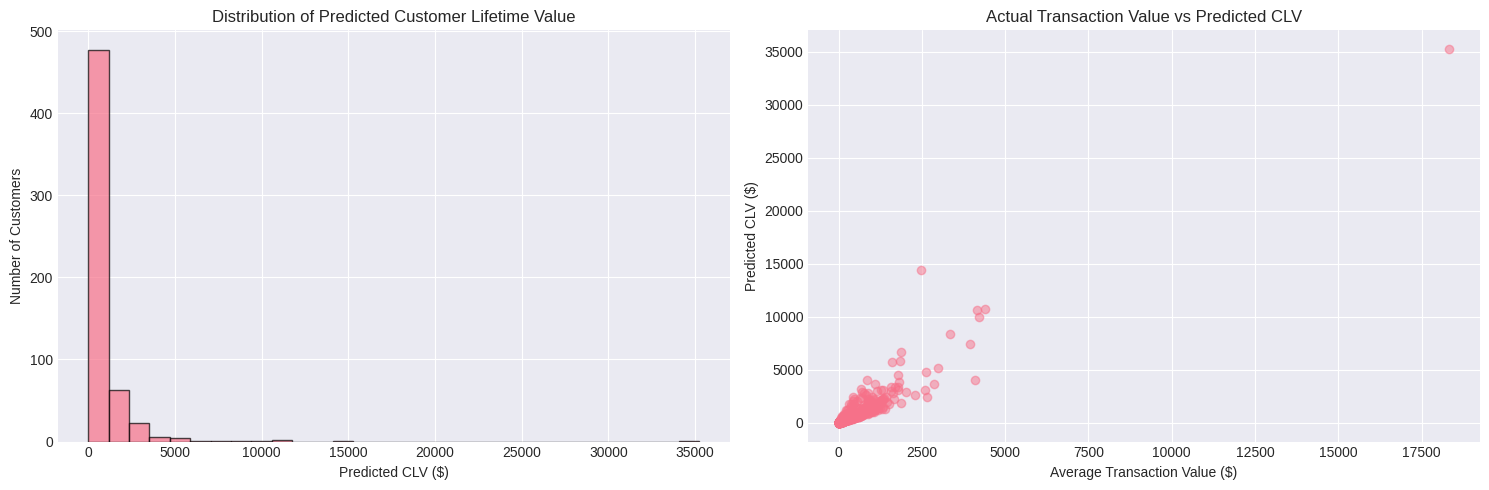

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v


 Saved CLV predictions to 'clv_predictions.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [17]:

# SECTION 10: CUSTOMER LIFETIME VALUE PREDICTION


print(" PREDICTING CUSTOMER LIFETIME VALUE")
print("="*60)

def predict_clv(transactions_df, customer_id_col, order_date_col, sales_col,
                frequency_col='total_orders', monetary_col='total_sales'):
    """
    Predict Customer Lifetime Value using Beta-Geometric/NBD model
    """

    print("\n Preparing data for CLV model...")

    # Create summary data from transactions
    summary = summary_data_from_transaction_data(
        transactions_df,
        customer_id_col=customer_id_col,
        datetime_col=order_date_col,
        monetary_value_col=sales_col,
        observation_period_end=transactions_df[order_date_col].max()
    )

    print(f" Summary data created for {len(summary)} customers")
    print("\nSummary statistics:")
    print(summary.describe())

    # Filter out customers with zero repeat purchases
    summary_repeat = summary[summary['frequency'] > 0]
    print(f"\n Customers with repeat purchases: {len(summary_repeat)}")

    if len(summary_repeat) < 10:
        print(" Not enough repeat customers for CLV modeling")
        return None, None

    # 1. Fit BG/NBD model for purchase frequency
    print("\n Fitting BG/NBD model...")
    bgf = BetaGeoFitter(penalizer_coef=0.1) # Added a small penalizer_coef
    bgf.fit(summary_repeat['frequency'], summary_repeat['recency'], summary_repeat['T'])
    print(" BG/NBD model fitted")

    # Predict future purchases for next 30, 60, 90 days
    for days in [30, 60, 90]:
        summary_repeat[f'predicted_purchases_{days}d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
            days, summary_repeat['frequency'], summary_repeat['recency'], summary_repeat['T']
        )

    # 2. Fit Gamma-Gamma model for monetary value
    print("\n Fitting Gamma-Gamma model...")
    ggf = GammaGammaFitter(penalizer_coef=0.1) # Added a small penalizer_coef
    ggf.fit(summary_repeat['frequency'], summary_repeat['monetary_value'])
    print(" Gamma-Gamma model fitted")

    # Predict CLV for next 12 months
    summary_repeat['predicted_clv'] = ggf.customer_lifetime_value(
        bgf,
        summary_repeat['frequency'],
        summary_repeat['recency'],
        summary_repeat['T'],
        summary_repeat['monetary_value'],
        time=12,  # 12 months
        discount_rate=0.01  # monthly discount rate
    )

    # Add to original dataframe
    summary_repeat = summary_repeat.reset_index()

    return summary_repeat, (bgf, ggf)

# Perform CLV prediction
if len(df_clean) > 1000:  # Only if we have enough data
    clv_results, models = predict_clv(
        df_clean,
        customer_id_col=customer_id_col,
        order_date_col='order_date',
        sales_col=sales_col
    )

    if clv_results is not None:
        print("\n CLV prediction complete!")
        print("\nTop 10 customers by predicted CLV:")
        top_clv = clv_results.nlargest(10, 'predicted_clv')[[customer_id_col, 'monetary_value', 'frequency', 'predicted_clv']]
        print(top_clv)

        # Visualize CLV distribution
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Distribution of predicted CLV
        axes[0].hist(clv_results['predicted_clv'], bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Predicted CLV ($)')
        axes[0].set_ylabel('Number of Customers')
        axes[0].set_title('Distribution of Predicted Customer Lifetime Value')

        # Actual vs Predicted (scatter)
        axes[1].scatter(clv_results['monetary_value'], clv_results['predicted_clv'], alpha=0.5)
        axes[1].set_xlabel('Average Transaction Value ($)')
        axes[1].set_ylabel('Predicted CLV ($)')
        axes[1].set_title('Actual Transaction Value vs Predicted CLV')

        plt.tight_layout()
        plt.show()

        # Save results
        clv_results.to_csv('clv_predictions.csv', index=False)
        print("\n Saved CLV predictions to 'clv_predictions.csv'")
else:
    print(" Not enough data for CLV prediction (need at least 1000 transactions)")

In [24]:

# SECTION 11: EXPORT RESULTS FOR POWER BI
print(" EXPORTING RESULTS FOR POWER BI")
print("="*60)

# 1. Create Star Schema for Power BI

# DimCustomer
dim_customer = customer_360_with_rfm[[
    customer_id_col, region_col, 'value_tier', 'frequency_tier',
    'Customer_Segment', 'total_sales', 'total_orders', 'avg_order_value'
]].copy()
dim_customer.columns = ['CustomerID', 'Region', 'ValueTier', 'FrequencyTier',
                        'Segment', 'TotalSales', 'TotalOrders', 'AvgOrderValue']
dim_customer.to_csv('DimCustomer.csv', index=False)
print(" Exported DimCustomer.csv")

# DimProduct
if 'product_id' in df_clean.columns:
    dim_product = df_clean[['product_id', 'category', 'subcategory']].drop_duplicates().copy()
    dim_product.columns = ['ProductID', 'Category', 'SubCategory']
    dim_product.to_csv('DimProduct.csv', index=False)
    print(" Exported DimProduct.csv")

# DimDate
# Extract unique dates first to ensure consistent length for DataFrame creation
unique_dates = df_clean['order_date'].dt.date.unique()
unique_dates_series = pd.Series(unique_dates)

dim_date = pd.DataFrame({
    'DateID': range(1, len(unique_dates) + 1),
    'Date': unique_dates,
    'Year': pd.to_datetime(unique_dates_series).dt.year,
    'Month': pd.to_datetime(unique_dates_series).dt.month,
    'MonthName': pd.to_datetime(unique_dates_series).dt.month_name(),
    'Quarter': pd.to_datetime(unique_dates_series).dt.quarter,
    'DayOfWeek': pd.to_datetime(unique_dates_series).dt.dayofweek,
    'DayName': pd.to_datetime(unique_dates_series).dt.day_name()
})
dim_date.to_csv('DimDate.csv', index=False)
print(" Exported DimDate.csv")

# FactSales
fact_sales = df_clean[[
    order_id_col, customer_id_col, 'order_date', sales_col, quantity_col, profit_col
]].copy()
fact_sales.columns = ['OrderID', 'CustomerID', 'OrderDate', 'Sales', 'Quantity', 'Profit']
fact_sales['DateID'] = fact_sales['OrderDate'].dt.date.map(
    dim_date.set_index('Date')['DateID'].to_dict()
)
fact_sales.to_csv('FactSales.csv', index=False)
print(" Exported FactSales.csv")

# 2. Create summary tables for Power BI

# Segment summary
segment_summary = customer_360_with_rfm.groupby('Customer_Segment').agg({
    customer_id_col: 'count',
    'total_sales': ['sum', 'mean'],
    'total_orders': ['sum', 'mean'],
    'total_profit': 'sum'
}).round(2)
segment_summary.columns = ['CustomerCount', 'TotalSales', 'AvgSales', 'TotalOrders', 'AvgOrders', 'TotalProfit']
segment_summary = segment_summary.reset_index()
segment_summary.to_csv('SegmentSummary.csv', index=False)
print(" Exported SegmentSummary.csv")

# Monthly trends
monthly_trends = df_clean.groupby(df_clean['order_date'].dt.to_period('M')).agg({
    sales_col: 'sum',
    order_id_col: 'nunique',
    quantity_col: 'sum',
    profit_col: 'sum'
}).reset_index()
monthly_trends['order_date'] = monthly_trends['order_date'].astype(str)
monthly_trends.columns = ['Month', 'Sales', 'Orders', 'Quantity', 'Profit']
monthly_trends.to_csv('MonthlyTrends.csv', index=False)
print(" Exported MonthlyTrends.csv")

# Create a zip file with all exports
!zip -r power_bi_exports.zip *.csv
print("\n Created power_bi_exports.zip with all CSV files")

# Download the zip file
files.download('power_bi_exports.zip')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 EXPORTING RESULTS FOR POWER BI
 Exported DimCustomer.csv
 Exported DimDate.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 Exported FactSales.csv
 Exported SegmentSummary.csv
 Exported MonthlyTrends.csv
  adding: cleaned_data.csv

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [27]:

# SECTION 12: AUTOMATION SETUP
print(" SETTING UP AUTOMATION")
print("="*60)

# This section shows how to automate the entire pipeline
# For Google Colab, you can use scheduled notebooks or convert to Python script

def run_complete_pipeline(data_file_path):
    """
    Complete pipeline function that can be scheduled
    """
    print("="*60)
    print("STARTING CONSUMER360 PIPELINE")
    print("="*60)

    # 1. Load data
    print("\n1. Loading data...")
    if data_file_path.endswith('.csv'):
        df = pd.read_csv(data_file_path)
    else:
        df = pd.read_excel(data_file_path)

    # 2. Clean data
    print("\n2. Cleaning data...")
    # Add your cleaning logic here

    # 3. Create customer 360
    print("\n3. Creating Customer 360 view...")
    # Add your customer 360 logic here

    # 4. Perform RFM
    print("\n4. Performing RFM segmentation...")
    # Add RFM logic here

    # 5. Export results
    print("\n5. Exporting results...")
    # Add export logic here

    print("\n" + "="*60)
    print("PIPELINE COMPLETE!")
    print("="*60)

    return "Success"

print("\n Pipeline function created!")
print("\nTo automate weekly runs:")
print("1. Convert this notebook to a Python script:")
print("   !jupyter nbconvert --to script Consumer360.ipynb")
print("\n2. Schedule using crontab (Linux/Mac) or Task Scheduler (Windows)")
print("\nExample crontab for weekly Sunday night run:")
print("0 2 * * 0 /usr/bin/python3 /path/to/Consumer360.py")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 SETTING UP AUTOMATION

 Pipeline function created!

To automate weekly runs:
1. Convert this notebook to a Python script:
   !jupyter nbconvert --to script Consumer360.ipynb

2. Schedule using crontab (Linux/Mac) or Task Scheduler (Windows)

Example crontab for weekly Sunday night run:
0 2 * * 0 /usr/bin/python3 /path/to/Consumer360.py


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [29]:
# SECTION 13: SUMMARY AND KEY INSIGHTS
print(" CONSUMER360 - KEY INSIGHTS SUMMARY")
print("="*60)

# Calculate key metrics
total_customers = len(customer_360_with_rfm)
total_revenue = customer_360_with_rfm['total_sales'].sum()
avg_revenue_per_customer = total_revenue / total_customers
champions_count = len(customer_360_with_rfm[customer_360_with_rfm['Customer_Segment'] == 'Champions'])
at_risk_count = len(customer_360_with_rfm[customer_360_with_rfm['Customer_Segment'].str.contains('At Risk|Hibernating|Lost')])

print(f"\n OVERALL METRICS:")
print(f"   Total Customers: {total_customers:,}")
print(f"   Total Revenue: ${total_revenue:,.2f}")
print(f"   Avg Revenue per Customer: ${avg_revenue_per_customer:,.2f}")
print(f"   Champions: {champions_count:,} ({champions_count/total_customers*100:.1f}%)")
print(f"   At Risk/Lost: {at_risk_count:,} ({at_risk_count/total_customers*100:.1f}%)")

print(f"\n TOP SEGMENTS BY REVENUE:")
segment_revenue = customer_360_with_rfm.groupby('Customer_Segment')['total_sales'].sum().sort_values(ascending=False)
for segment, revenue in segment_revenue.head().items():
    print(f"   {segment}: ${revenue:,.2f} ({revenue/total_revenue*100:.1f}%)")

print(f"\n REGIONAL PERFORMANCE:")
if region_col in customer_360_with_rfm.columns:
    region_perf = customer_360_with_rfm.groupby(region_col).agg({
        'total_sales': 'sum',
        customer_id_col: 'count' # Fixed: Using customer_id_col instead of hardcoded 'customer_id'
    }).round(2)
    region_perf.columns = ['Revenue', 'Customers']
    region_perf['Revenue_per_Customer'] = region_perf['Revenue'] / region_perf['Customers']
    print(region_perf)

print(f"\n ANALYSIS COMPLETE!")
print("\n Generated files:")
print("   1. cleaned_data.csv - Cleaned transaction data")
print("   2. customer_360.csv - Customer metrics view")
print("   3. customer_segments.csv - RFM segments")
print("   4. association_rules.csv - Market basket analysis")
print("   5. clv_predictions.csv - CLV predictions")
print("   6. power_bi_exports.zip - Star schema for Power BI")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

 CONSUMER360 - KEY INSIGHTS SUMMARY

 OVERALL METRICS:
   Total Customers: 738
   Total Revenue: $887,917.23
   Avg Revenue per Customer: $1,203.14
   Champions: 109 (14.8%)
   At Risk/Lost: 266 (36.0%)

 TOP SEGMENTS BY REVENUE:
   Champions: $287,051.86 (32.3%)
   At Risk Champions: $114,851.38 (12.9%)
   Potential Loyalists: $107,176.13 (12.1%)
   At Risk: $97,537.06 (11.0%)
   Loyal Customers: $81,069.05 (9.1%)

 REGIONAL PERFORMANCE:
           Revenue  Customers  Revenue_per_Customer
Region                                             
Central  231363.40        175           1322.076571
East     205208.37        200           1026.041850
South    145218.53        129           1125.725039
West     306126.93        234           1308.234744

 ANALYSIS COMPLETE!

 Generated files:
   1. cleaned_data.csv - Cleaned transaction data
   2. customer_360.csv - Customer metrics view
   3. customer_segments.csv - RFM segments
   4. association_rules.csv - Market basket analysis
   5. clv_pr

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v